In [58]:
from typing import TypedDict,Literal
from langgraph.graph import StateGraph,START,END

In [59]:
class Quadstate(TypedDict):
    a:int
    b:int
    c:int

    equation:str
    discriminant:float
    result:str

In [60]:
graph = StateGraph(Quadstate)
    

In [61]:
def showequation(state:Quadstate):
    equation = f"Quadratic equation : {state['a']}x2 + {state['b']}x + {state['c']}"
    return {'equation':equation}


In [62]:
def calcDiscriminant(state:Quadstate):
      discriminant = state['b']**2 - 4*state['a']*state['c']
      return {'discriminant':discriminant}


In [63]:
def real_roots(state:Quadstate):
    #D>0
    root1 = (-state['b'] + state['discriminant']**0.5)/(2*state["a"]) 
    root2 = (-state['b'] - state['discriminant']**0.5)/(2*state["a"])
    result = f"the roots are {root1} and {root2}"
    return {"result": result}

In [64]:
def repeated_roots(state:Quadstate):
    #D=0
    root = -(state['b']) /(2*state['a'])       
    result = f"Only repeated root is {root}"
    return {"result":result}

In [65]:
def norealroots(state:Quadstate):
    #D<0
    result = "no real roots"
    return {"result":result}

In [66]:
def checkCondition(state:Quadstate)->Literal["real_roots","repeated_roots","norealroots"]:
    if state["discriminant"] > 0:
        return "real_roots"
    elif state["discriminant"] == 0:
        return "repeated_roots"
    else :
        return "norealroots"

In [67]:
graph.add_node("showequation",showequation)
graph.add_node("calculateDiscriminant",calcDiscriminant)
graph.add_node("real_roots",real_roots)
graph.add_node("repeated_roots",repeated_roots)
graph.add_node("norealroots",norealroots)
graph.add_edge(START,"showequation")
graph.add_edge("showequation","calculateDiscriminant")
graph.add_conditional_edges("calculateDiscriminant",checkCondition)


In [68]:
workflow = graph.compile()

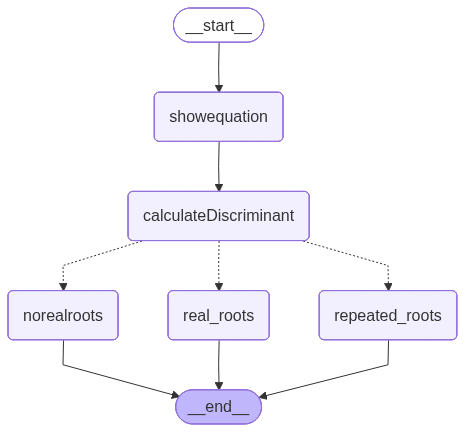

In [69]:
workflow

In [70]:
input={
    'a':-1,
    'b':-1,
    'c':-2
}

In [71]:
workflow.invoke(input)

{'a': -1,
 'b': -1,
 'c': -2,
 'equation': 'Quadratic equation : -1x2 + -1x + -2',
 'discriminant': -7,
 'result': 'no real roots'}